In [3]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft
from scipy.signal import stft, find_peaks
import pandas as pd


In [4]:
def Nacti_soubor(cesta_k_souboru): return wfdb.rdrecord(cesta_k_souboru)

{'record_name': 'voice001', 'n_sig': 1, 'fs': 8000, 'counter_freq': None, 'base_counter': None, 'sig_len': 38080, 'base_time': None, 'base_date': None, 'comments': ['<age>: 32  <sex>: M <diagnoses>: hyperkinetic dysphonia <medications>: none'], 'sig_name': ['voice'], 'p_signal': array([[ 0.        ],
       [ 0.        ],
       [ 0.        ],
       ...,
       [ 0.00354004],
       [-0.03735352],
       [-0.02871704]]), 'd_signal': None, 'e_p_signal': None, 'e_d_signal': None, 'file_name': ['voice001.dat'], 'fmt': ['32'], 'samps_per_frame': [1], 'skew': [None], 'byte_offset': [None], 'adc_gain': [4079702243.3775], 'baseline': [-260023747], 'units': ['NU'], 'adc_res': [0], 'adc_zero': [0], 'init_value': [-260023747], 'checksum': [14973], 'block_size': [0]}


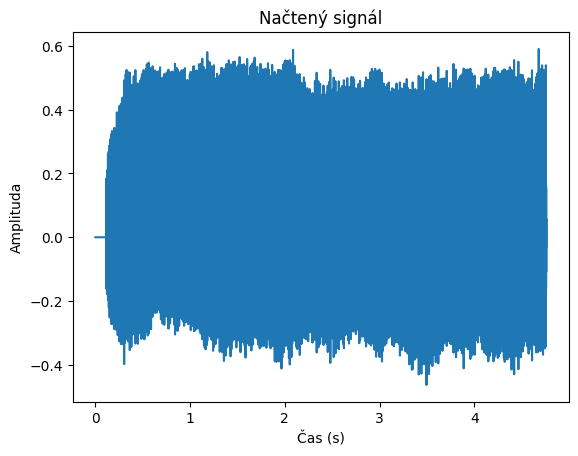

In [17]:
record = Nacti_soubor("C:\\Users\\ondra\\OneDrive\\Plocha\\voice-icar-federico-ii-database-1.0.0\\voice001") #načtu si zvukový soubor
# Výpis dostupných atributů
print(record.__dict__)

# Výběr prvního signálového kanálu (pokud existuje více kanálů)
signal = record.p_signal[:, 0] if record.p_signal.ndim > 1 else record.p_signal

# Získání vzorkovací frekvence
vz_f = record.fs if hasattr(record, 'fs') else 1  # Defaultně 1 Hz, pokud není dostupná

# Výpočet délky audia
time = len(signal) / vz_f

# Časová osa
time_axis = np.linspace(0, time, len(signal))

# Zobrazení signálu
plt.plot(time_axis, signal)
plt.xlabel("Čas (s)")
plt.ylabel("Amplituda")
plt.title("Načtený signál")
plt.show()




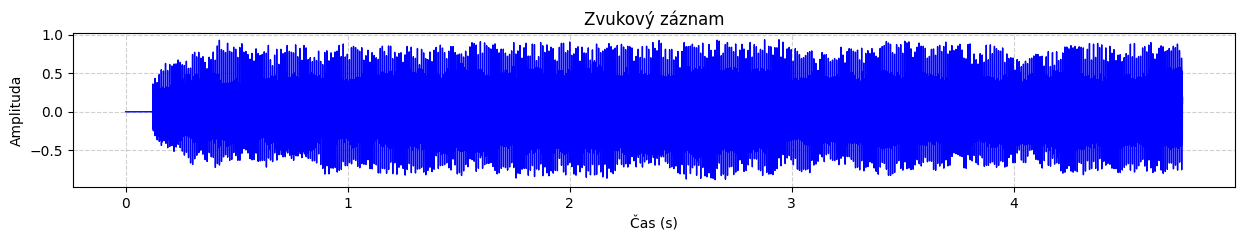

In [31]:
#vykreslení audia
def plot_audio(time_axis, signal):
    fig, ax = plt.subplots(figsize=(15, 2))
    ax.plot(time_axis, signal, color='blue', linewidth=1)
    ax.set_title("Zvukový záznam")
    ax.set_xlabel("Čas (s)")
    ax.set_ylabel("Amplituda")
    ax.grid(True, linestyle='--', alpha=0.6)
    plt.show()

#přehrání audia
def play_audio(signal, fs):
    norm_signal = signal / np.max(np.abs(signal))  # Normalizace do intervalu [-1,1]
    audio_data = np.clip(norm_signal * 32767, -32768, 32767).astype(np.int16)  # Převod na 16bit PCM
    sd.play(audio_data, samplerate=fs)
    sd.wait()

plot_audio(time_axis,signal)
play_audio(signal, vz_f) 

In [26]:

def plot_fft_signal(fqs_axis, spectrum, peak_fqs, peaks, fqs2_axis, modified_spectrum, 
                    fqs3_axis, log_sp, fqs4_axis, cepstrum, signal_name):
    
    fig, axes = plt.subplots(4, 1, figsize=(18, 12), sharex=False)
    
    # FFT spektrum
    axes[0].plot(fqs_axis, spectrum, label="FFT Spektrum", color='blue')
    axes[0].scatter(peak_fqs, peaks, color='red', marker='o', label="R-vrcholy")
    axes[0].set_title(f"FFT spektrum signálu: {signal_name}")
    axes[0].set_ylabel("Amplituda (Hz)")
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.6)

    # Modifikované spektrum
    axes[1].plot(fqs2_axis, modified_spectrum, color='green')
    axes[1].set_title("Modifikované spektrum signálu")
    axes[1].set_ylabel("Amplituda (Hz)")
    axes[1].grid(True, linestyle='--', alpha=0.6)

    # Logaritmické spektrum
    axes[2].plot(fqs3_axis, log_sp, color='purple')
    axes[2].set_title("Logaritmické spektrum signálu")
    axes[2].set_ylabel("Amplituda (Hz)")
    axes[2].grid(True, linestyle='--', alpha=0.6)

    # Kepstrální analýza
    axes[3].plot(fqs4_axis, cepstrum, color='orange')
    axes[3].set_title("Kepstrální analýza signálu")
    axes[3].set_xlabel("Frekvence (Hz)")
    axes[3].set_ylabel("Amplituda")
    axes[3].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()


In [27]:

def vypocet_prumerne_frekvence(amplitudy, dolni_mez):
    # Filtrování hodnot nad dolní mez
    vybrane_hodnoty = [uV for uV in amplitudy if uV > dolni_mez]
    
    # Pokud existují platné hodnoty, vrátí se průměr, jinak None
    return np.mean(vybrane_hodnoty) if vybrane_hodnoty else None


In [28]:
import numpy as np
from scipy.signal import find_peaks

def fft_transform(signal, fs, down_limit, signal_range=0.2):
    # Fourierova transformace
    _1D_f_t = np.fft.fft(signal)
    fft_spectrum = np.abs(_1D_f_t)  # Spektrum Fourierovy transformace
    
    # Osa frekvencí pro FFT
    fqs_t = np.fft.fftfreq(len(signal), 1/fs)[:len(signal)//2]  # Pouze pozitivní frekvence
    
    # Vytvoření modifikovaného spektra (mazání vrcholů nad dolní mez)
    modified_spectrum = np.copy(fft_spectrum)
    modified_spectrum[modified_spectrum > down_limit] = 0
    
    # Logaritmické spektrum
    log_sp = np.log(fft_spectrum**2 + 1e-10)  # +1e-10 pro prevenci log(0)
    
    # Inversní Fourierova transformace pro kepstrální analýzu
    invers_fft = np.abs(np.fft.ifft(log_sp))  # Kepstrální analýza
    
    # Detekce vrcholů (frekvence s amplitudou nad dolní mezí)
    peaks, _ = find_peaks(fft_spectrum, height=down_limit)
    peak_fqs = fqs_t[peaks]  # Freqvence, kde jsou vrcholy
    peak_magnitudes = fft_spectrum[peaks]  # Magnitudy těchto vrcholů
    
    return fqs_t, fft_spectrum[:len(signal)//2], modified_spectrum[:len(signal)//2], log_sp[:len(signal)//2], invers_fft[:len(signal)//2], peak_magnitudes, peak_fqs


In [33]:
def count_fft_pathology(fft_spectrum, mean_threshold, min_threshold, max_threshold, std_threshold):
    # Získání základních statistik spektra
    min_value = np.min(fft_spectrum)
    max_value = np.max(fft_spectrum)
    mean_value = np.mean(fft_spectrum)
    std_value = np.std(fft_spectrum)
    
    # Uložení statistik do slovníku
    stats = {
        "min_value": min_value,
        "max_value": max_value,
        "mean_value": mean_value,
        "std_value": std_value,
    }
    
    # Detekce patologických hodnot
    pathology_info = []
    if min_value < min_threshold:
        pathology_info.append("min_value below threshold")
    if max_value > max_threshold:
        pathology_info.append("max_value above threshold")
    if mean_value > mean_threshold:
        pathology_info.append("mean_value above threshold")
    if std_value > std_threshold:
        pathology_info.append("std_value above threshold")
    
    # Zjištění patologičnosti
    is_pathological = len(pathology_info) > 0
    
    # Přidání informací o patologii
    stats["is_pathological"] = is_pathological
    stats["pathology_info"] = pathology_info if is_pathological else ["No pathology detected"]
    
    return stats
peaks_limit = 0.8 #nastavím si dolní hranici pro vrcholy např.: 0.5 Hz


In [1]:


def plot_fft_signal(fqs, spectrum, peak_fqs, peaks, fqs2, modified_spectrum, fqs3, log_spectrum, fqs4, ifft_spectrum, signal_name):
    # Vytvoření figure pro všechny grafy
    plt.figure(figsize=(20, 10))
    
    # První subplot: FFT spektrum signálu
    plt.subplot(4, 1, 1)
    plt.plot(fqs, spectrum, label="FFT Spectrum")
    plt.plot(peak_fqs, peaks, linestyle='None', marker='o', color='red', label="R-vrcholy")
    plt.title(f"FFT Spektrum signálu: {signal_name}")
    plt.xlabel("Frekvence (Hz)")
    plt.ylabel("Amplituda")
    plt.grid()
    plt.legend()

    # Druhý subplot: Modifikované spektrum signálu
    plt.subplot(4, 1, 2)
    plt.plot(fqs2, modified_spectrum, label="Modified Spectrum", color='green')
    plt.title(f"Modifikované spektrum signálu")
    plt.xlabel("Frekvence (Hz)")
    plt.ylabel("Amplituda")
    plt.grid()
    plt.legend()

    # Třetí subplot: Logaritmické spektrum signálu
    plt.subplot(4, 1, 3)
    plt.plot(fqs3, log_spectrum, label="Log Spectrum", color='orange')
    plt.title("Logaritmické spektrum signálu")
    plt.xlabel("Frekvence (Hz)")
    plt.ylabel("Logaritmická Amplituda")
    plt.grid()
    plt.legend()

    # Čtvrtý subplot: Inversní Fourierova transformace (Kepstrální analýza)
    plt.subplot(4, 1, 4)
    plt.plot(fqs4, ifft_spectrum, label="Inverse FFT (Cepstrum)", color='purple')
    plt.title("Inverzní FFT - Kepstrální analýza")
    plt.xlabel("Frekvence (Hz)")
    plt.ylabel("Amplituda")
    plt.grid()
    plt.legend()

    # Automatické uspořádání grafů
    plt.tight_layout()
    
    # Zobrazení grafů
    plt.show()
